## EDA3-模型预测效果探索性分析

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 读取数据
df = pd.read_csv('../results/predictions/direct/lightgbm_smape_probe/test_predictions.csv')
df['预测日期'] = pd.to_datetime(df['预测日期'])

# 提取实际值和预测值
hours = list(range(24))
actual_cols = [f'actual_H{h:02d}' for h in hours]
pred_cols = [f'pred_H{h:02d}' for h in hours]

# 计算误差指标
def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    return mae, rmse, smape

# 计算每小时指标
hourly_metrics = []
for h in hours:
    actual = df[f'actual_H{h:02d}'].values
    pred = df[f'pred_H{h:02d}'].values
    mae, rmse, smape = calculate_metrics(actual, pred)
    hourly_metrics.append({'hour': h, 'mae': mae, 'rmse': rmse, 'smape': smape})

metrics_df = pd.DataFrame(hourly_metrics)

# 准备长格式数据用于绘图
df_melted = []
for _, row in df.iterrows():
    date = row['预测日期']
    for h in hours:
        df_melted.append({
            'date': date,
            'hour': h,
            'actual': row[f'actual_H{h:02d}'],
            'predicted': row[f'pred_H{h:02d}']
        })
df_long = pd.DataFrame(df_melted)

C:\Users\31238\AppData\Local\Temp\ipykernel_4532\4243004594.py:87: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
c:\Users\31238\.conda\envs\epftoolbox\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


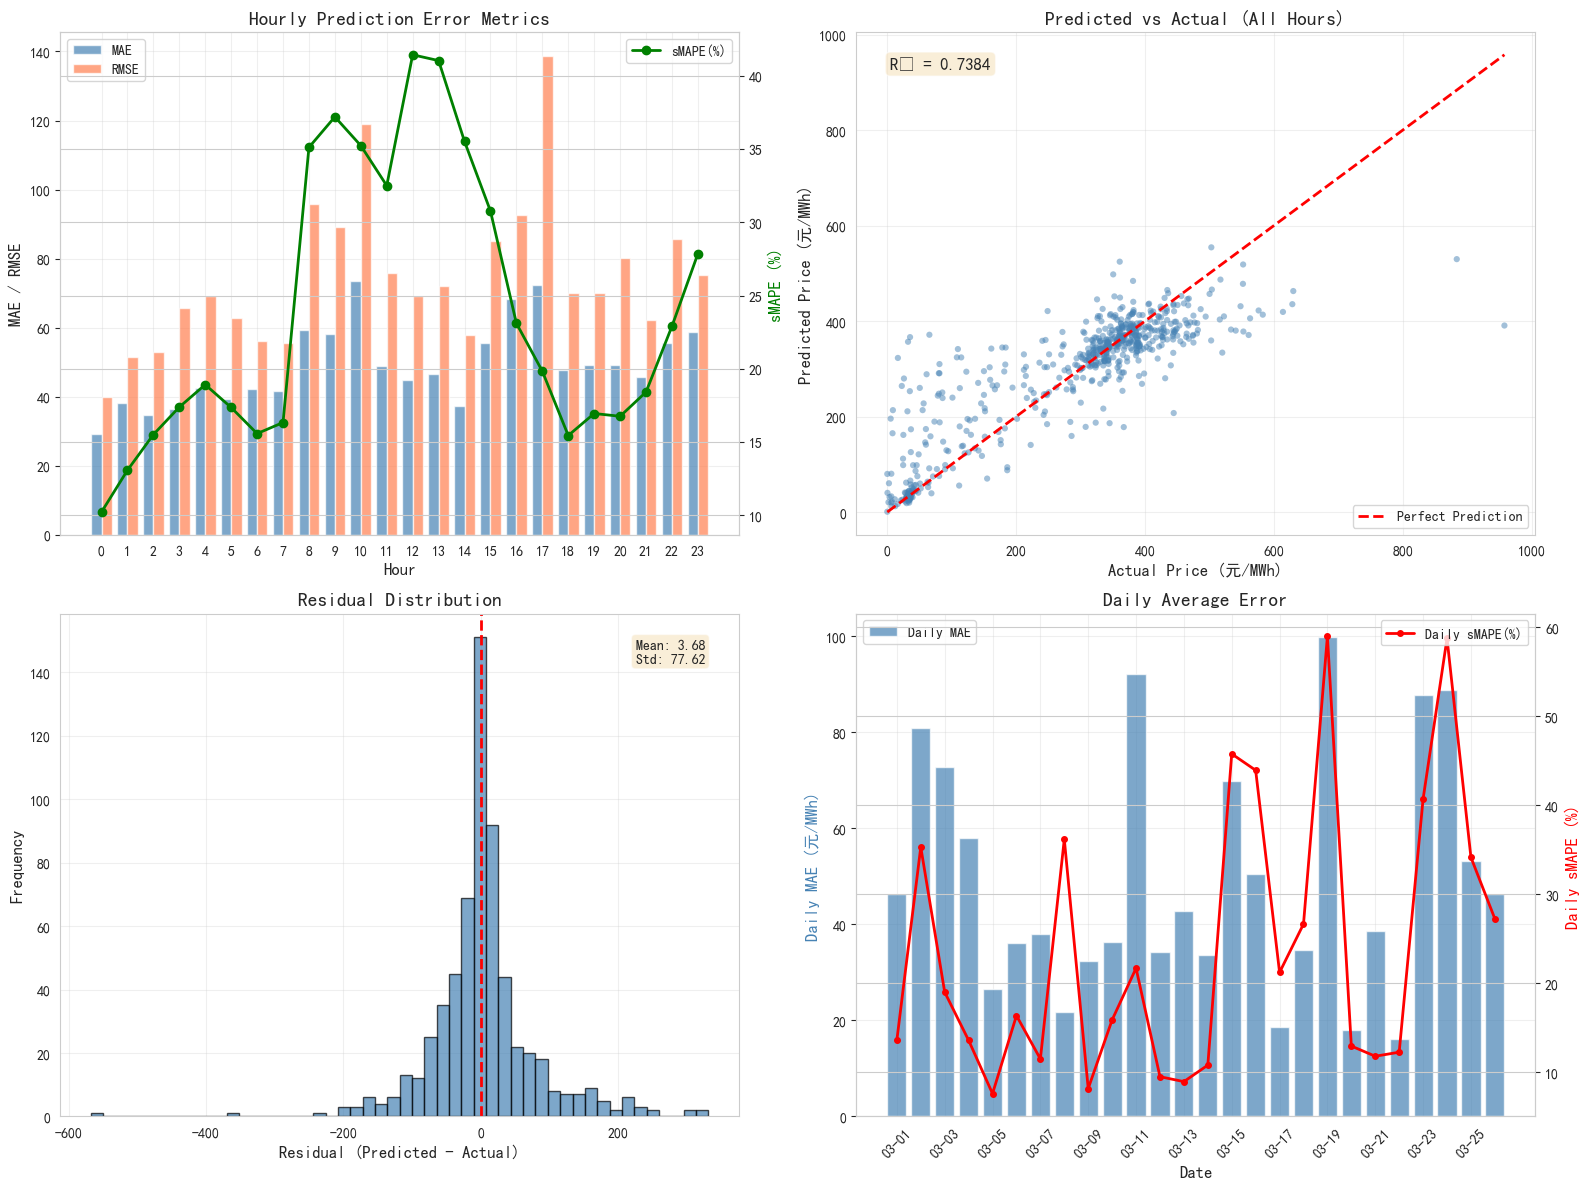

In [6]:
# 图1: 24小时平均预测效果对比
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图1: 每小时MAE/RMSE/sMAPE
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
bars1 = ax1.bar(metrics_df['hour'] - 0.2, metrics_df['mae'], 0.4, label='MAE', color='steelblue', alpha=0.7)
bars2 = ax1.bar(metrics_df['hour'] + 0.2, metrics_df['rmse'], 0.4, label='RMSE', color='coral', alpha=0.7)
line = ax1_twin.plot(metrics_df['hour'], metrics_df['smape'], 'g-o', label='sMAPE(%)', linewidth=2, markersize=6)
ax1.set_xlabel('Hour', fontsize=12)
ax1.set_ylabel('MAE / RMSE', fontsize=12)
ax1_twin.set_ylabel('sMAPE (%)', fontsize=12, color='green')
ax1.set_title('Hourly Prediction Error Metrics', fontsize=14, fontweight='bold')
ax1.set_xticks(hours)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 子图2: 散点图 - 预测值 vs 实际值
ax2 = axes[0, 1]
all_actual = df[actual_cols].values.flatten()
all_pred = df[pred_cols].values.flatten()
ax2.scatter(all_actual, all_pred, alpha=0.5, s=20, c='steelblue', edgecolors='none')
min_val = min(all_actual.min(), all_pred.min())
max_val = max(all_actual.max(), all_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Price (元/MWh)', fontsize=12)
ax2.set_ylabel('Predicted Price (元/MWh)', fontsize=12)
ax2.set_title('Predicted vs Actual (All Hours)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 计算R²
from sklearn.metrics import r2_score
r2 = r2_score(all_actual, all_pred)
ax2.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax2.transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图3: 残差分布
ax3 = axes[1, 0]
residuals = all_pred - all_actual
ax3.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Residual (Predicted - Actual)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Residual Distribution', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 添加统计信息
mean_res = np.mean(residuals)
std_res = np.std(residuals)
ax3.text(0.95, 0.95, f'Mean: {mean_res:.2f}\nStd: {std_res:.2f}', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 计算每日每小时的绝对误差
error_matrix = np.zeros((len(df), 24))
for i, row in df.iterrows():
    for h in hours:
        error_matrix[i, h] = abs(row[f'pred_H{h:02d}'] - row[f'actual_H{h:02d}'])

# 子图4: 每日平均误差对比
ax4 = axes[1, 1]
daily_mae = np.mean(error_matrix, axis=1)
daily_smape = []
for i, row in df.iterrows():
    actual_day = [row[f'actual_H{h:02d}'] for h in hours]
    pred_day = [row[f'pred_H{h:02d}'] for h in hours]
    _, _, smape = calculate_metrics(np.array(actual_day), np.array(pred_day))
    daily_smape.append(smape)

dates = df['预测日期'].dt.strftime('%m-%d')
ax4_twin = ax4.twinx()
bars = ax4.bar(range(len(dates)), daily_mae, color='steelblue', alpha=0.7, label='Daily MAE')
line = ax4_twin.plot(range(len(dates)), daily_smape, 'r-o', linewidth=2, markersize=4, label='Daily sMAPE(%)')

ax4.set_xlabel('Date', fontsize=12)
ax4.set_ylabel('Daily MAE (元/MWh)', fontsize=12, color='steelblue')
ax4_twin.set_ylabel('Daily sMAPE (%)', fontsize=12, color='red')
ax4.set_title('Daily Average Error', fontsize=14, fontweight='bold')
ax4.set_xticks(range(0, len(dates), max(1, len(dates)//10)))
ax4.set_xticklabels([dates.iloc[i] for i in range(0, len(dates), max(1, len(dates)//10))], rotation=45)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

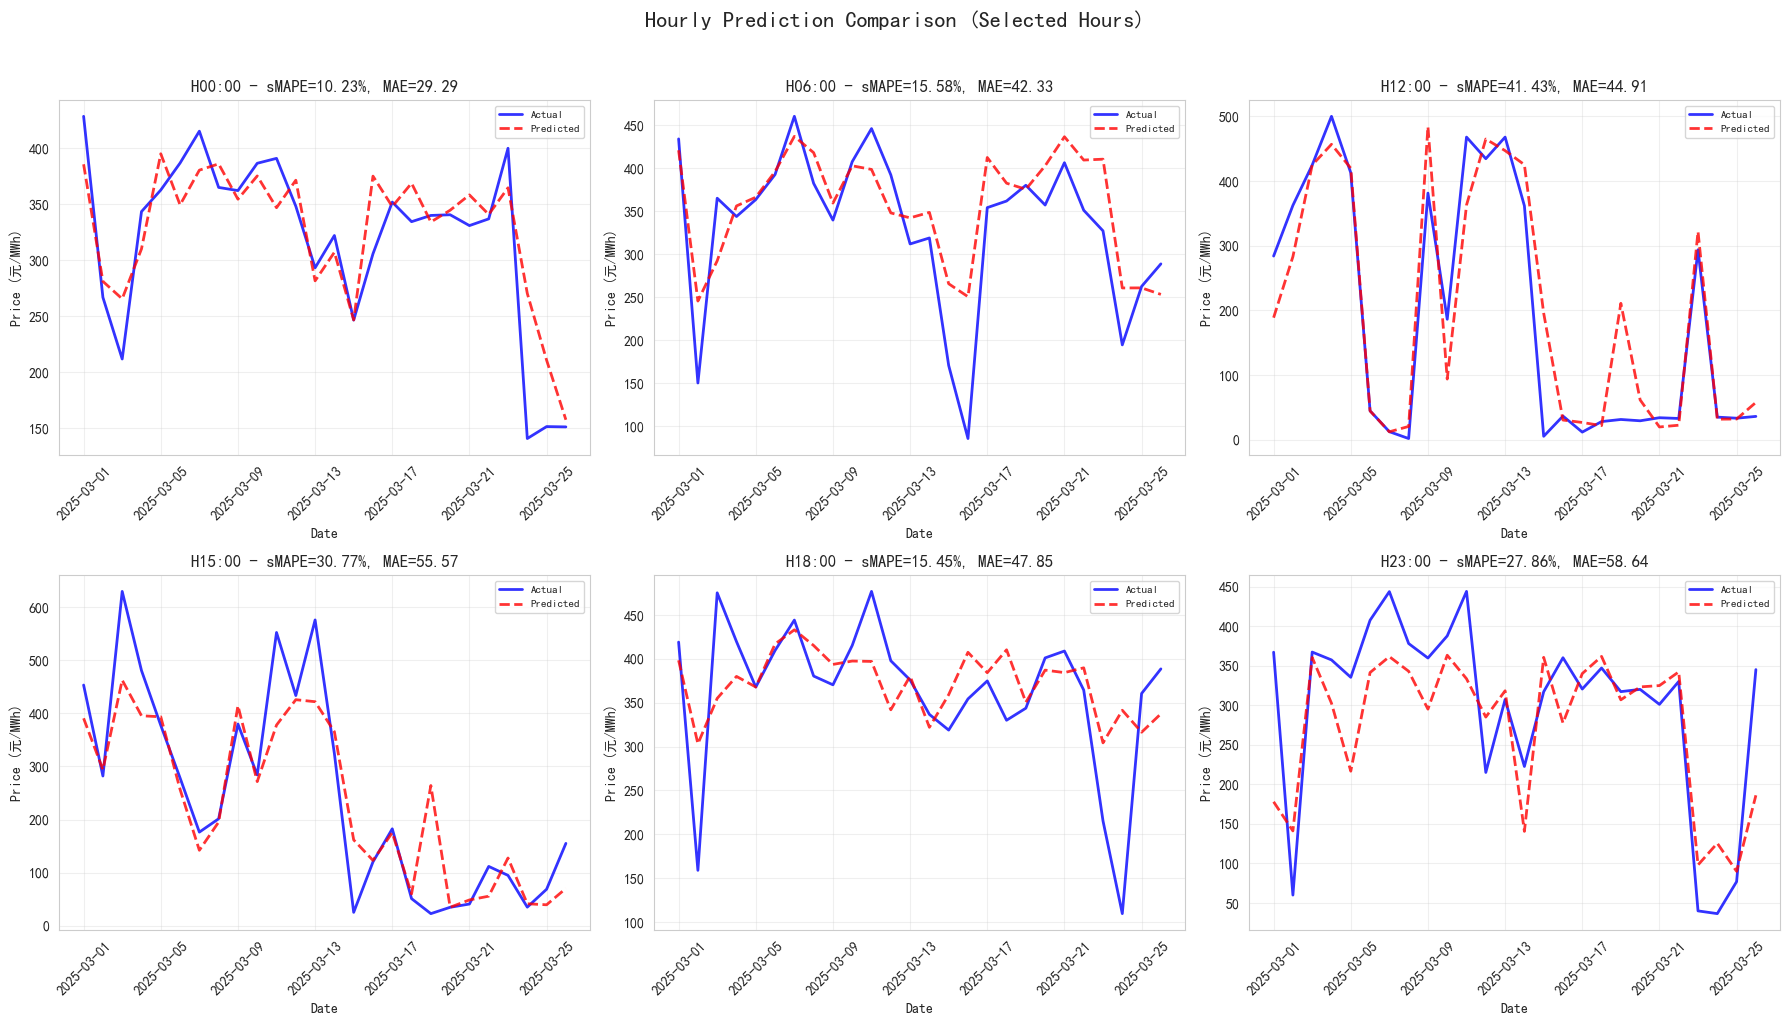

In [9]:
# 图3: 特定小时的详细对比
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

selected_hours = [0, 6, 12, 15, 18, 23]  # 选择代表性小时

for idx, h in enumerate(selected_hours):
    ax = axes[idx]
    actual = df[f'actual_H{h:02d}'].values
    pred = df[f'pred_H{h:02d}'].values
    
    ax.plot(df['预测日期'], actual, 'b-', linewidth=2, label='Actual', alpha=0.8)
    ax.plot(df['预测日期'], pred, 'r--', linewidth=2, label='Predicted', alpha=0.8)
    
    mae, rmse, smape = calculate_metrics(actual, pred)
    ax.set_title(f'H{h:02d}:00 - sMAPE={smape:.2f}%, MAE={mae:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Price (元/MWh)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Hourly Prediction Comparison (Selected Hours)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

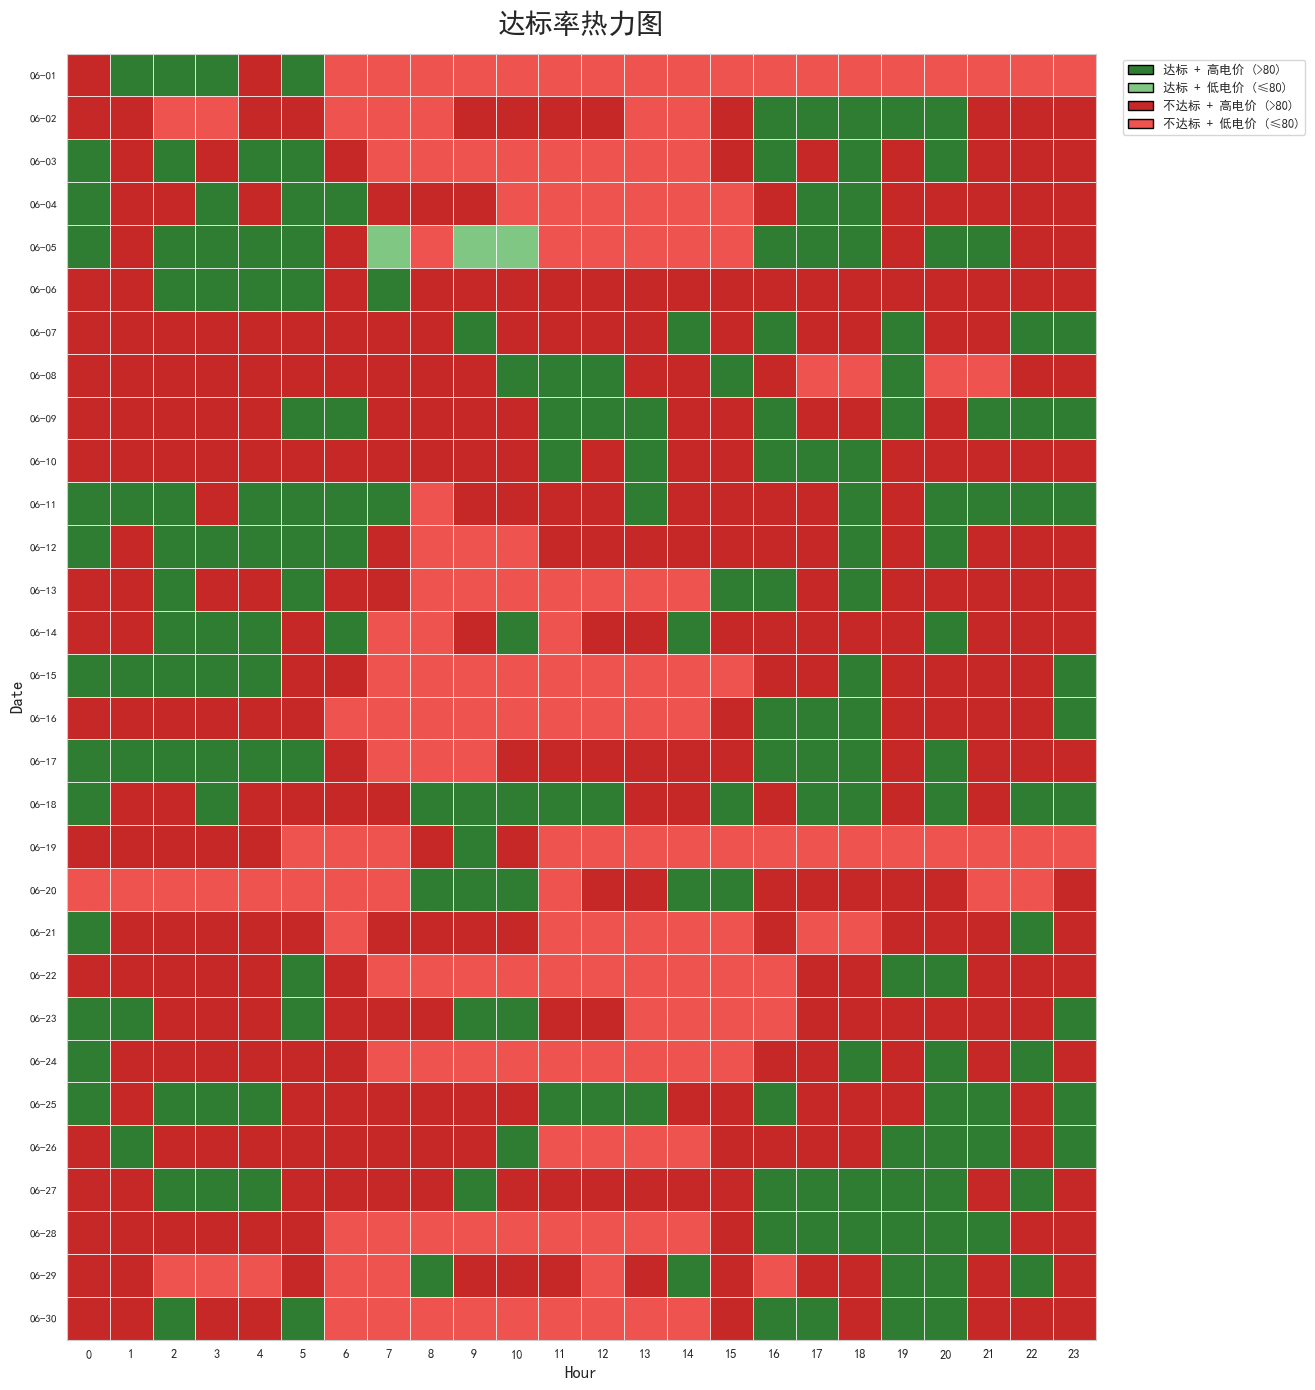

预测达标率统计
整体达标率 (sAPE < 20%): 27.50%
高电价时段达标率 (>80元/MWh): 35.71%
低电价时段达标率 (≤80元/MWh): 1.72%


In [3]:
# 计算sAPE函数
def calculate_sape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    sape = np.zeros_like(y_true, dtype=float)
    sape[mask] = np.abs(y_true[mask] - y_pred[mask]) / denominator[mask] * 100
    return sape

# 构建sAPE矩阵和价格矩阵
n_days = len(df)
sape_matrix = np.zeros((n_days, 24))
price_matrix = np.zeros((n_days, 24))

for i, row in df.iterrows():
    for h in hours:
        actual = row[f'actual_H{h:02d}']
        pred = row[f'pred_H{h:02d}']
        sape = calculate_sape(actual, pred)
        sape_matrix[i, h] = sape
        price_matrix[i, h] = actual

# 创建自定义颜色映射
# 达标(sAPE<20%): 绿色系；不达标: 红色系
# 高电价(>80): 深色；低电价(<=80): 浅色

def get_cell_color(sape, price):
    """
    根据sAPE和价格确定颜色
    - sape < 20: 达标(绿色)
    - sape >= 20: 不达标(红色)
    - price > 80: 深色
    - price <= 80: 浅色
    """
    is_good = sape < 20  # 达标
    is_high_price = price > 80  # 高电价
    
    if is_good and is_high_price:
        # 达标 + 高电价 = 深绿色
        return '#2E7D32'  # 深绿
    elif is_good and not is_high_price:
        # 达标 + 低电价 = 浅绿色
        return '#81C784'  # 浅绿
    elif not is_good and is_high_price:
        # 不达标 + 高电价 = 深红色
        return '#C62828'  # 深红
    else:
        # 不达标 + 低电价 = 浅红色
        return '#EF5350'  # 浅红

# 设置单元格大小为正方形，调整图片尺寸
cell_size = 0.4  # 每个单元格的大小
fig_width = 24 * cell_size + 3  # 宽度：24小时 + 边距
fig_height = n_days * cell_size + 2  # 高度：天数 + 边距

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 绘制每个单元格
for i in range(n_days):
    for j in range(24):
        color = get_cell_color(sape_matrix[i, j], price_matrix[i, j])
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, 
                            facecolor=color, edgecolor='white', linewidth=0.5)
        ax.add_patch(rect)

# 设置坐标轴
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(-0.5, n_days - 0.5)
ax.set_xticks(hours)
ax.set_xticklabels([f'{h}' for h in hours], fontsize=9)
ax.set_yticks(range(n_days))
ax.set_yticklabels([d.strftime('%m-%d') for d in df['预测日期']], fontsize=8)

ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Date', fontsize=12)
ax.set_title('达标率热力图', fontsize=20, fontweight='bold', pad=15)

# 图例
legend_elements = [
    mpatches.Patch(facecolor='#2E7D32', edgecolor='black', label='达标 + 高电价 (>80)'),
    mpatches.Patch(facecolor='#81C784', edgecolor='black', label='达标 + 低电价 (≤80)'),
    mpatches.Patch(facecolor='#C62828', edgecolor='black', label='不达标 + 高电价 (>80)'),
    mpatches.Patch(facecolor='#EF5350', edgecolor='black', label='不达标 + 低电价 (≤80)')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)

# 设置等比例
ax.set_aspect('equal')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# 统计信息
print("=" * 60)
print("预测达标率统计")
print("=" * 60)
overall_acc = np.mean(sape_matrix < 20) * 100
print(f"整体达标率 (sAPE < 20%): {overall_acc:.2f}%")

high_price_mask = price_matrix > 80
low_price_mask = ~high_price_mask
high_price_acc = np.mean(sape_matrix[high_price_mask] < 20) * 100 if np.any(high_price_mask) else 0
low_price_acc = np.mean(sape_matrix[low_price_mask] < 20) * 100 if np.any(low_price_mask) else 0

print(f"高电价时段达标率 (>80元/MWh): {high_price_acc:.2f}%")
print(f"低电价时段达标率 (≤80元/MWh): {low_price_acc:.2f}%")
print("=" * 60)

高电价天数: 10
低电价天数: 20


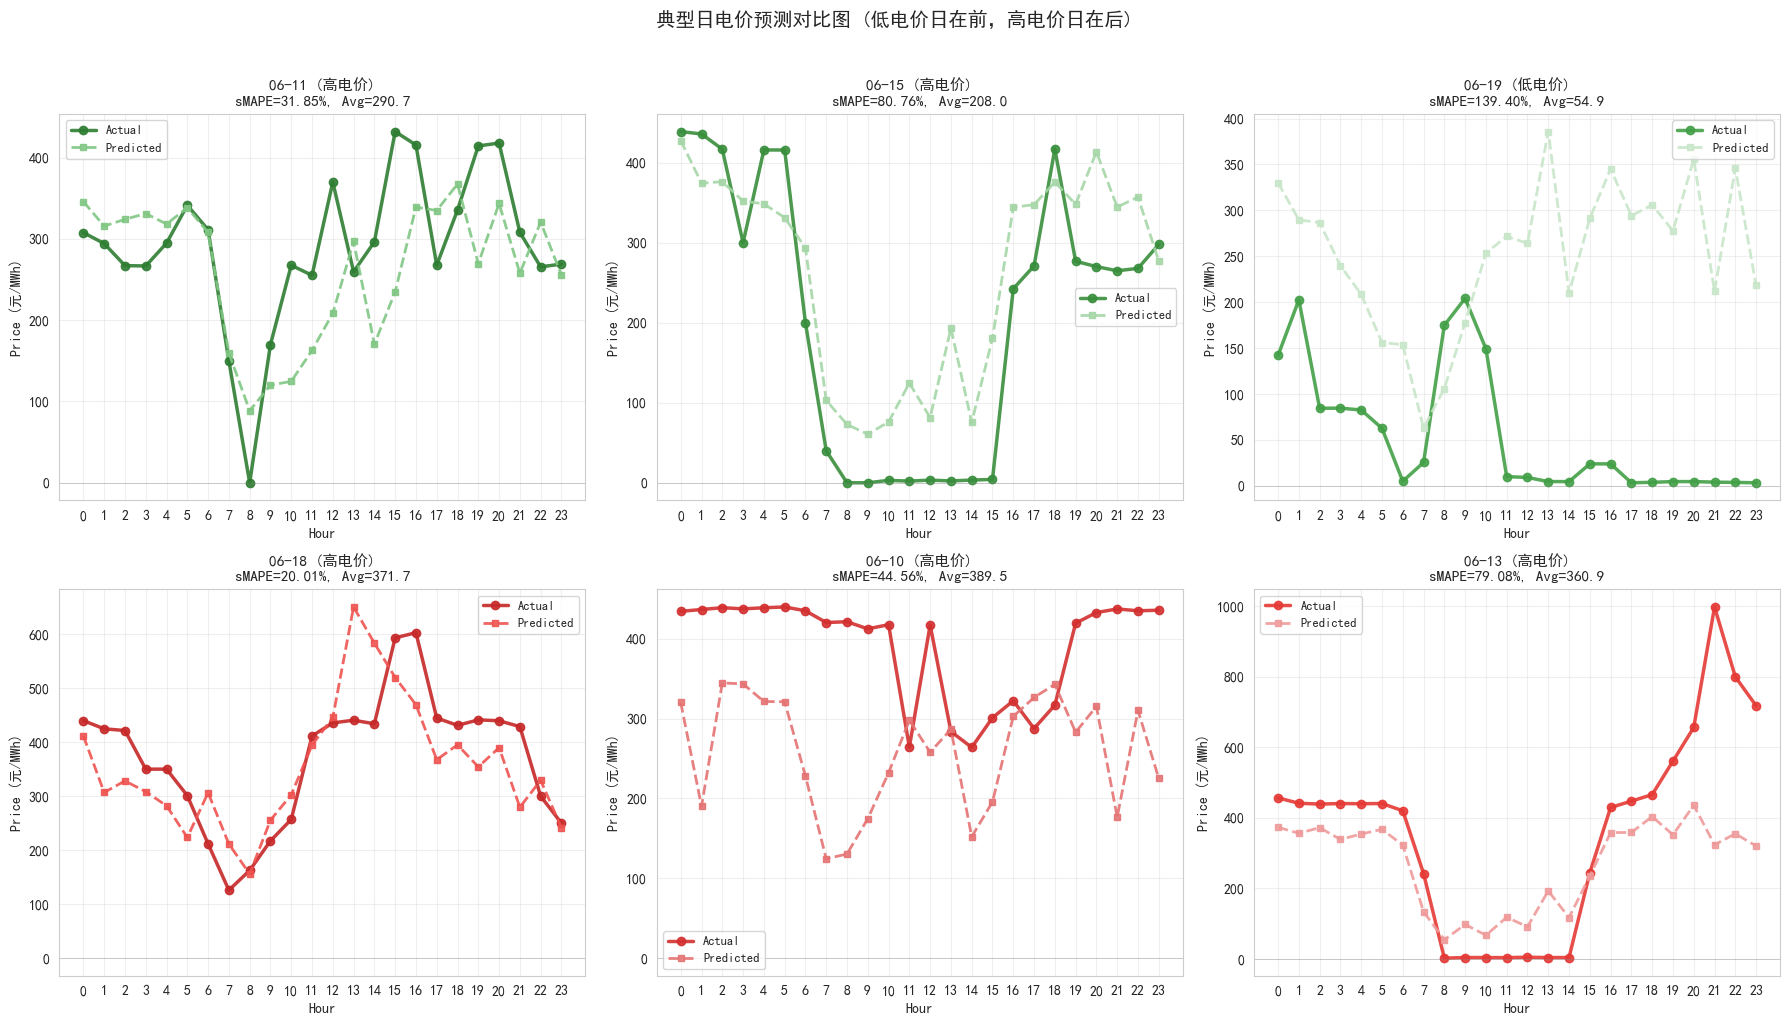


选中的典型日详情
类型       日期           平均sMAPE      平均电价         最大电价         最小电价        
--------------------------------------------------------------------------------
高电价      2025-06-11   31.85        290.70       432.00       0.00        
高电价      2025-06-15   80.76        207.96       439.00       0.00        
低电价      2025-06-19   139.40       54.95        204.10       3.20        
高电价      2025-06-18   20.01        371.72       603.20       126.00      
高电价      2025-06-10   44.56        389.47       439.70       263.90      
高电价      2025-06-13   79.08        360.91       997.10       2.30        


In [4]:
# 计算每天的平均sAPE、平均电价、最大电价
day_stats = []
for i, row in df.iterrows():
    actual_day = np.array([row[f'actual_H{h:02d}'] for h in hours])
    pred_day = np.array([row[f'pred_H{h:02d}'] for h in hours])
    
    sape_day = calculate_sape(actual_day, pred_day)
    avg_sape = np.mean(sape_day)
    avg_price = np.mean(actual_day)
    max_price = np.max(actual_day)
    min_price = np.min(actual_day)
    
    day_stats.append({
        'date': row['预测日期'],
        'avg_sape': avg_sape,
        'avg_price': avg_price,
        'max_price': max_price,
        'min_price': min_price,
        'actual': actual_day,
        'pred': pred_day
    })

stats_df = pd.DataFrame(day_stats)

# 定义高电价和低电价
high_price_days = stats_df[(stats_df['avg_price'] > 300)]
low_price_days = stats_df[(stats_df['avg_price'] <= 300)]

print(f"高电价天数: {len(high_price_days)}")
print(f"低电价天数: {len(low_price_days)}")

# 从高电价中选3天：sMAPE最低、中等、最高
if len(high_price_days) >= 3:
    high_sorted = high_price_days.sort_values('avg_sape')
    high_selected = pd.concat([
        high_sorted.iloc[[0]],
        high_sorted.iloc[[len(high_sorted)//2]],
        high_sorted.iloc[[-1]]
    ])
else:
    high_selected = high_price_days

# 从低电价中选3天：sMAPE最低、中等、最高
if len(low_price_days) >= 3:
    low_sorted = low_price_days.sort_values('avg_sape')
    low_selected = pd.concat([
        low_sorted.iloc[[0]],
        low_sorted.iloc[[len(low_sorted)//2]],
        low_sorted.iloc[[-1]]
    ])
else:
    low_selected = low_price_days

# 合并选中的天数
selected_days = pd.concat([low_selected, high_selected]).reset_index(drop=True)
n_selected = len(selected_days)

# 根据选中天数确定子图布局
if n_selected <= 3:
    fig, axes = plt.subplots(1, n_selected, figsize=(6*n_selected, 5))
else:
    n_rows = (n_selected + 2) // 3  # 向上取整
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))

# 确保axes是数组
if n_selected == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_selected > 3 else [axes] if n_selected == 1 else axes

colors_actual = ['#2E7D32', '#388E3C', '#43A047', '#C62828', '#D32F2F', '#E53935']
colors_pred = ['#81C784', '#A5D6A7', '#C8E6C9', '#EF5350', '#E57373', '#EF9A9A']

for idx in range(n_selected):
    ax = axes[idx]
    day = selected_days.iloc[idx]
    
    actual = day['actual']
    pred = day['pred']
    date_str = day['date'].strftime('%m-%d')
    avg_sape = day['avg_sape']
    avg_price = day['avg_price']
    
    price_type = "高电价" if avg_price > 200 or day['max_price'] > 400 else "低电价"
    
    ax.plot(hours, actual, 'o-', linewidth=2.5, markersize=6, 
            color=colors_actual[idx], label='Actual', alpha=0.9)
    ax.plot(hours, pred, 's--', linewidth=2, markersize=5, 
            color=colors_pred[idx], label='Predicted', alpha=0.9)
    
    ax.set_title(f'{date_str} ({price_type})\nsMAPE={avg_sape:.2f}%, Avg={avg_price:.1f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=10)
    ax.set_ylabel('Price (元/MWh)', fontsize=10)
    ax.set_xticks(hours)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# 隐藏多余的子图
for idx in range(n_selected, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('典型日电价预测对比图 (低电价日在前，高电价日在后)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# 打印选中天的详细信息
print("\n" + "=" * 80)
print("选中的典型日详情")
print("=" * 80)
print(f"{'类型':<8} {'日期':<12} {'平均sMAPE':<12} {'平均电价':<12} {'最大电价':<12} {'最小电价':<12}")
print("-" * 80)
for _, day in selected_days.iterrows():
    price_type = "高电价" if day['avg_price'] > 200 or day['max_price'] > 400 else "低电价"
    print(f"{price_type:<8} {day['date'].strftime('%Y-%m-%d'):<12} "
          f"{day['avg_sape']:<12.2f} {day['avg_price']:<12.2f} "
          f"{day['max_price']:<12.2f} {day['min_price']:<12.2f}")
print("=" * 80)

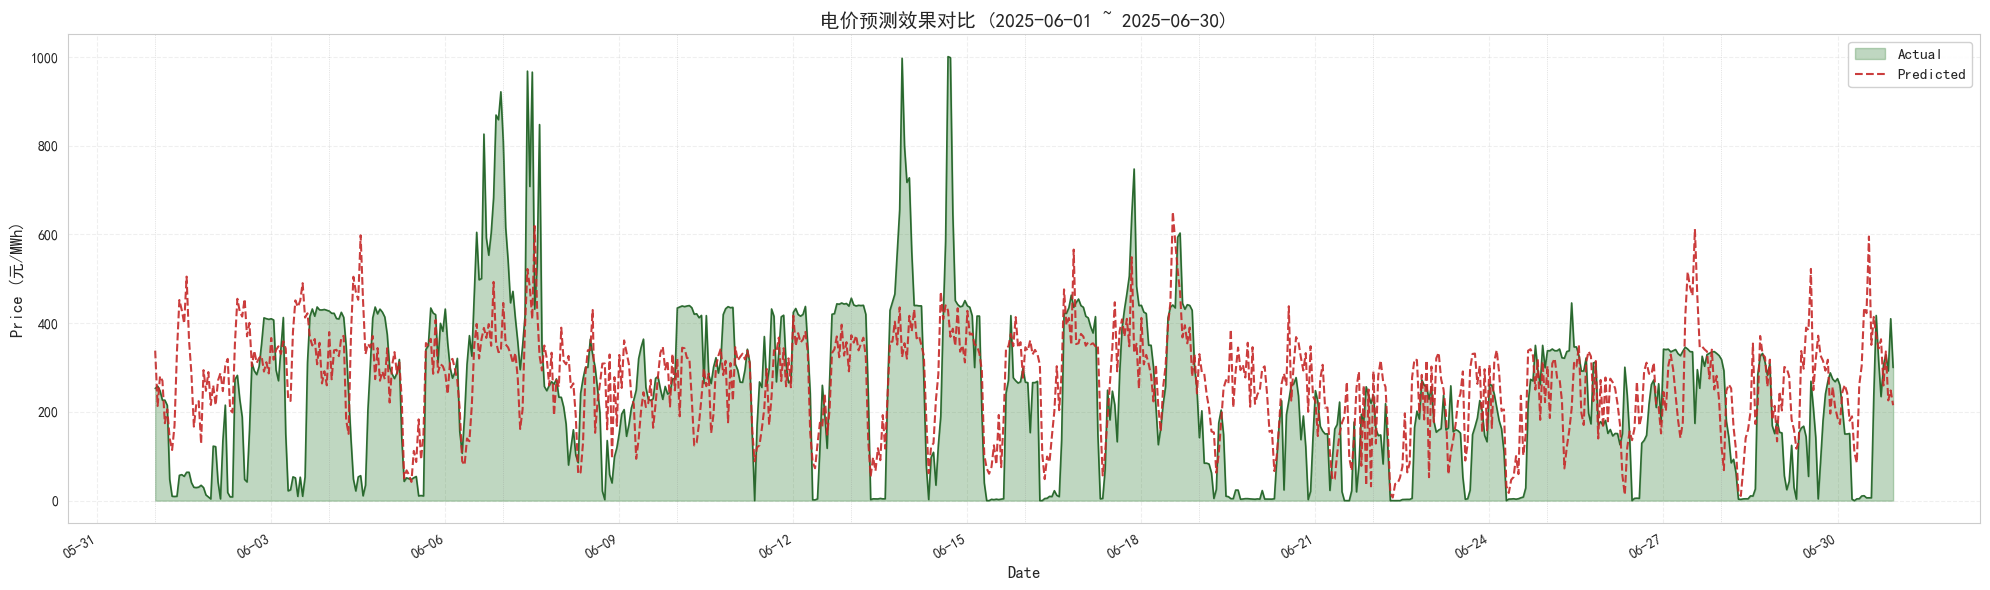

In [5]:
# 绘制完整月份的预测和真实值对比时间序列图（简洁美观版）
fig, ax = plt.subplots(figsize=(20, 6))

# 将数据转换为长格式
all_data = []
for _, row in df.iterrows():
    date = row['预测日期']
    for h in hours:
        all_data.append({
            'datetime': date + pd.Timedelta(hours=h),
            'actual': row[f'actual_H{h:02d}'],
            'predicted': row[f'pred_H{h:02d}']
        })

df_long = pd.DataFrame(all_data)

# 绘制真实值和预测值
ax.fill_between(df_long['datetime'], df_long['actual'], alpha=0.3, 
                color='#2E7D32', label='Actual')
ax.plot(df_long['datetime'], df_long['actual'], '-', linewidth=1.2, 
        color='#1B5E20', alpha=0.9)
ax.plot(df_long['datetime'], df_long['predicted'], '--', linewidth=1.5, 
        color='#C62828', label='Predicted', alpha=0.9)

# 设置标题和标签
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (元/MWh)', fontsize=12)
ax.set_title(f'电价预测效果对比 ({df["预测日期"].min().strftime("%Y-%m-%d")} ~ {df["预测日期"].max().strftime("%Y-%m-%d")})', 
             fontsize=14, fontweight='bold')

# 添加图例
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# 添加网格
ax.grid(True, alpha=0.3, linestyle='--')

# 格式化x轴
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# 添加每日分隔线
for date in df['预测日期'].unique()[::3]:
    ax.axvline(x=date, color='gray', linestyle=':', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()